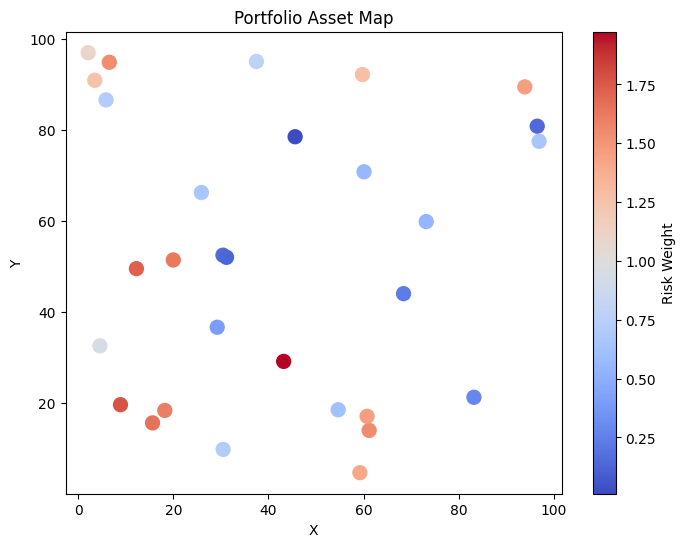

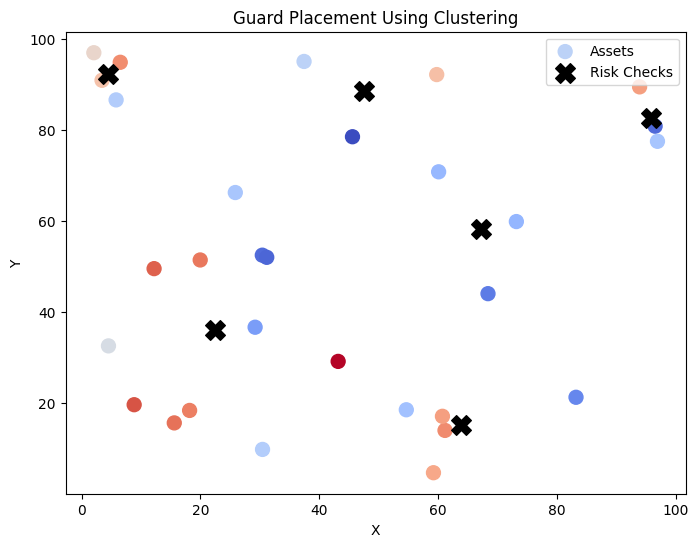

Guard 1 covers 3 shocks out of 8
Guard 2 covers 1 shocks out of 8
Guard 3 covers 0 shocks out of 8
Guard 4 covers 2 shocks out of 8
Guard 5 covers 2 shocks out of 8
Guard 6 covers 0 shocks out of 8


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

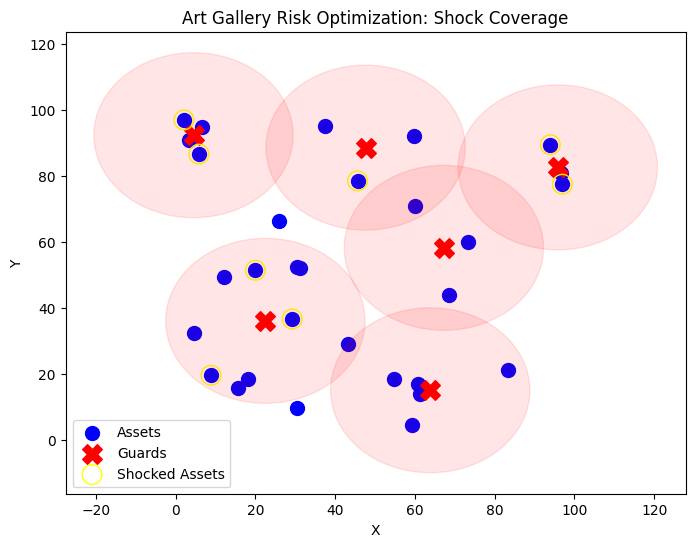

Total portfolio shocks covered: 8/8 (100.00%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random
np.random.seed(42)
num_assets = 30
assets = np.random.rand(num_assets, 2) * 100  # coordinates
risk_weights = np.random.rand(num_assets) * 2  # importance score from 0 to 2

# Plot assets
plt.figure(figsize=(8,6))
plt.scatter(assets[:,0], assets[:,1], c=risk_weights, cmap='coolwarm', s=100)
plt.colorbar(label='Risk Weight')
plt.title("Portfolio Asset Map")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
num_guards = 6
kmeans = KMeans(n_clusters=num_guards, random_state=42).fit(assets)
guards = kmeans.cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(assets[:,0], assets[:,1], c=risk_weights, cmap='coolwarm', s=100, label='Assets')
plt.scatter(guards[:,0], guards[:,1], c='black', marker='X', s=200, label='Risk Checks')
plt.title("Guard Placement Using Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
coverage_radius = 25  # distance threshold for coverage
num_shocks = 8
shocks = random.sample(range(num_assets), num_shocks)

coverage_matrix = np.zeros((num_guards, num_shocks))

for i, g in enumerate(guards):
    for j, s in enumerate(shocks):
        distance = np.linalg.norm(g - assets[s])
        if distance <= coverage_radius:
            coverage_matrix[i,j] = 1

# Print coverage
for i in range(num_guards):
    print(f"Guard {i+1} covers {int(coverage_matrix[i].sum())} shocks out of {num_shocks}")
    plt.figure(figsize=(8,6))
plt.scatter(assets[:,0], assets[:,1], c='blue', s=100, label='Assets')
plt.scatter(guards[:,0], guards[:,1], c='red', marker='X', s=200, label='Guards')

# Highlight shocked assets
plt.scatter(assets[shocks,0], assets[shocks,1], facecolors='none', edgecolors='yellow', s=200, label='Shocked Assets')

# Draw coverage circles
for g in guards:
    circle = plt.Circle((g[0], g[1]), coverage_radius, color='red', alpha=0.1)
    plt.gca().add_patch(circle)

plt.title("Art Gallery Risk Optimization: Shock Coverage")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
total_covered = np.sum(coverage_matrix.any(axis=0))
coverage_percent = total_covered / num_shocks * 100
print(f"Total portfolio shocks covered: {total_covered}/{num_shocks} ({coverage_percent:.2f}%)")